# 03 — Training Data Analysis

This notebook audits the labelled training table used for the Ahmedabad–Gandhinagar Sentinel-2 land-cover classification workflow.

**Goals**
- Load the existing training table without changing it.
- Check schema, dimensions, missing values, duplicate records, and feature ranges.
- Summarize the number of samples per land-cover class.
- Visualize class balance and selected feature distributions.
- Review spatial coverage when coordinates are available in the source table or an optional training-point vector file.

**Important interpretation note:** the project currently has a small labelled dataset (about 33 valid rows were reported after cleaning, while the source table has also been observed with 39 rows). This notebook reports what is present in the files at runtime rather than assuming either count. Class-wise sample counts and plots are diagnostics; they do not prove map accuracy or eliminate spatial sampling bias.

Run from the repository root or from the `notebooks/` directory. This notebook is read-only: it does not edit or overwrite the input dataset.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Find the repository root whether Jupyter was started from the root or notebooks/.
CANDIDATE_ROOTS = [Path.cwd(), Path.cwd().parent]
ROOT = next((p for p in CANDIDATE_ROOTS if (p / "outputs").exists() and (p / "data").exists()), Path.cwd())
DATASET_PATH = ROOT / "outputs" / "training_dataset.csv"

print("Repository root:", ROOT)
print("Training dataset:", DATASET_PATH)
print("Dataset exists:", DATASET_PATH.exists())
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATASET_PATH}. Run this notebook from the repository root "
        "or notebooks/ and confirm outputs/training_dataset.csv exists."
    )

Repository root: c:\Users\lenovo\Desktop\satellite-land-cover-classification
Training dataset: c:\Users\lenovo\Desktop\satellite-land-cover-classification\outputs\training_dataset.csv
Dataset exists: True


## 1. Load and inspect the dataset

The table is expected to contain spectral bands/indices and labels such as `class_name` and `class_id`. The notebook detects columns rather than assuming every optional field is present.

In [2]:
df = pd.read_csv(DATASET_PATH)

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns):,}")
display(df.head())
display(pd.DataFrame({
    "column": df.columns,
    "dtype": [str(dtype) for dtype in df.dtypes],
    "non_null": [int(df[c].notna().sum()) for c in df.columns],
    "missing": [int(df[c].isna().sum()) for c in df.columns],
}))

Rows: 39
Columns: 16


,sample_id,B02,B03,B04,B05,B06,B07,B08,B8A,B11,B12,NDVI,NDWI,NDBI,class_name,class_id
0,1,1265.0,1529.0,1316.0,1536.0,1302.0,1366.0,1317.0,1304.0,1322.0,1213.0,0.000380,0.074491,0.000356,vegetation,1
1,2,2820.0,3045.0,3335.0,3636.0,3714.0,3632.0,3557.0,3804.0,4173.0,3825.0,0.032211,-0.077552,0.058629,built_up,2
2,3,1678.0,2019.0,2395.0,2639.0,2754.0,2907.0,2871.0,3090.0,3876.0,3542.0,0.090391,-0.174233,0.154127,bare_soil,3
3,4,1256.0,1347.0,1219.0,1256.0,1289.0,1268.0,1325.0,1366.0,1347.0,1251.0,0.041667,0.008234,0.007955,water,4
4,5,1717.0,1801.0,1895.0,1984.0,2045.0,2099.0,2060.0,2175.0,2293.0,2071.0,0.041719,-0.067081,0.073129,road,5


,column,dtype,non_null,missing
0,sample_id,int64,39,0
1,B02,float64,39,0
2,B03,float64,39,0
3,B04,float64,39,0
4,B05,float64,39,0
5,B06,float64,39,0
6,B07,float64,39,0
7,B08,float64,39,0
8,B8A,float64,39,0
9,B11,float64,39,0


## 2. Data quality checks

These checks flag issues for review. They do not automatically drop records or change labels. Exact duplicate rows and duplicate sample identifiers can be meaningful clues, but should be investigated before any removal.

In [3]:
print("Exact duplicate rows:", int(df.duplicated().sum()))

id_candidates = [c for c in df.columns if c.lower() in {"sample_id", "point_id", "id"}]
for col in id_candidates:
    print(f"Duplicate non-null values in {col!r}:", int(df[col].dropna().duplicated().sum()))

missing_by_column = df.isna().sum().sort_values(ascending=False)
display(missing_by_column[missing_by_column > 0].to_frame("missing_count"))

if "class_name" in df.columns:
    print("Missing class labels:", int(df["class_name"].isna().sum()))
elif "class_id" in df.columns:
    print("Missing class IDs:", int(df["class_id"].isna().sum()))
else:
    warnings.warn("No class_name or class_id column was found; class-based analysis will be limited.")

Exact duplicate rows: 0
Duplicate non-null values in 'sample_id': 0


,missing_count


Missing class labels: 0


## 3. Class balance

Class imbalance affects how reliably a model can learn each class. A small number of samples—especially for spectrally similar classes such as built-up surfaces, bare soil, and roads—can lead to unstable metrics. The bar chart below reflects only the current table.

,sample_count
class,
vegetation,10
built_up,9
road,8
bare_soil,6
water,6


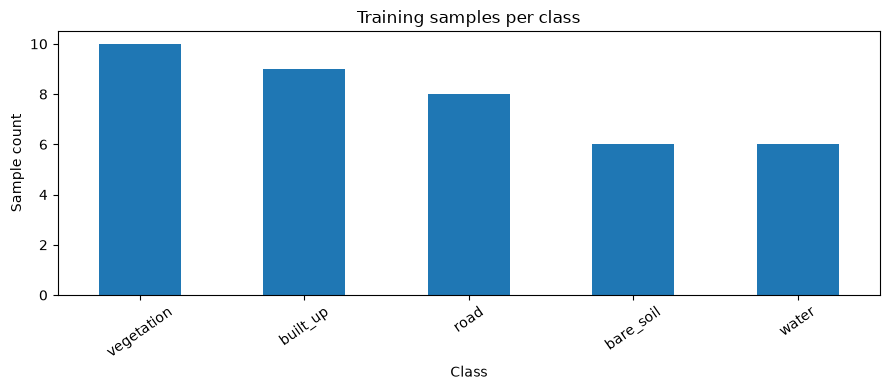

In [4]:
label_col = "class_name" if "class_name" in df.columns else ("class_id" if "class_id" in df.columns else None)

if label_col is None:
    print("No class label column found; skipping class balance.")
else:
    class_counts = df[label_col].fillna("MISSING").astype(str).value_counts(dropna=False)
    display(class_counts.rename_axis("class").to_frame("sample_count"))
    ax = class_counts.sort_values(ascending=False).plot(kind="bar", figsize=(9, 4))
    ax.set_title("Training samples per class")
    ax.set_xlabel("Class")
    ax.set_ylabel("Sample count")
    ax.tick_params(axis="x", rotation=35)
    plt.tight_layout()
    plt.show()

## 4. Numeric feature distributions

The following summary and histograms help identify suspicious ranges, constant columns, and extreme values. Reflectance scale and index definitions depend on the preprocessing workflow; do not interpret these numbers without checking how the input rasters and indices were produced.

Numeric feature columns: 15


,count,mean,std,min,25%,50%,75%,max
sample_id,39.0,20.000000,11.401754,1.000000,10.500000,20.000000,29.500000,39.000000
B02,39.0,1896.179487,733.580077,1161.000000,1335.000000,1717.000000,2196.000000,4032.000000
B03,39.0,2175.051282,817.159134,1246.000000,1614.000000,1842.000000,2460.500000,4359.000000
B04,39.0,2237.179487,995.041096,1152.000000,1334.500000,1954.000000,2715.500000,4491.000000
B05,39.0,2614.923077,983.605382,1163.000000,2048.500000,2498.000000,3445.000000,4717.000000
B06,39.0,3168.692308,1213.332994,1147.000000,2302.000000,3435.000000,4217.000000,4901.000000
B07,39.0,3313.948718,1311.509595,1180.000000,2427.000000,3632.000000,4364.500000,5677.000000
B08,39.0,3299.692308,1340.182021,1163.000000,2255.000000,3400.000000,4410.000000,5741.000000
B8A,39.0,3442.846154,1374.744446,1194.000000,2487.000000,3746.000000,4407.500000,5933.000000
B11,39.0,3192.230769,1140.005574,1283.000000,2478.500000,3351.000000,4115.500000,5374.000000


Numeric columns with at most one unique non-null value: None


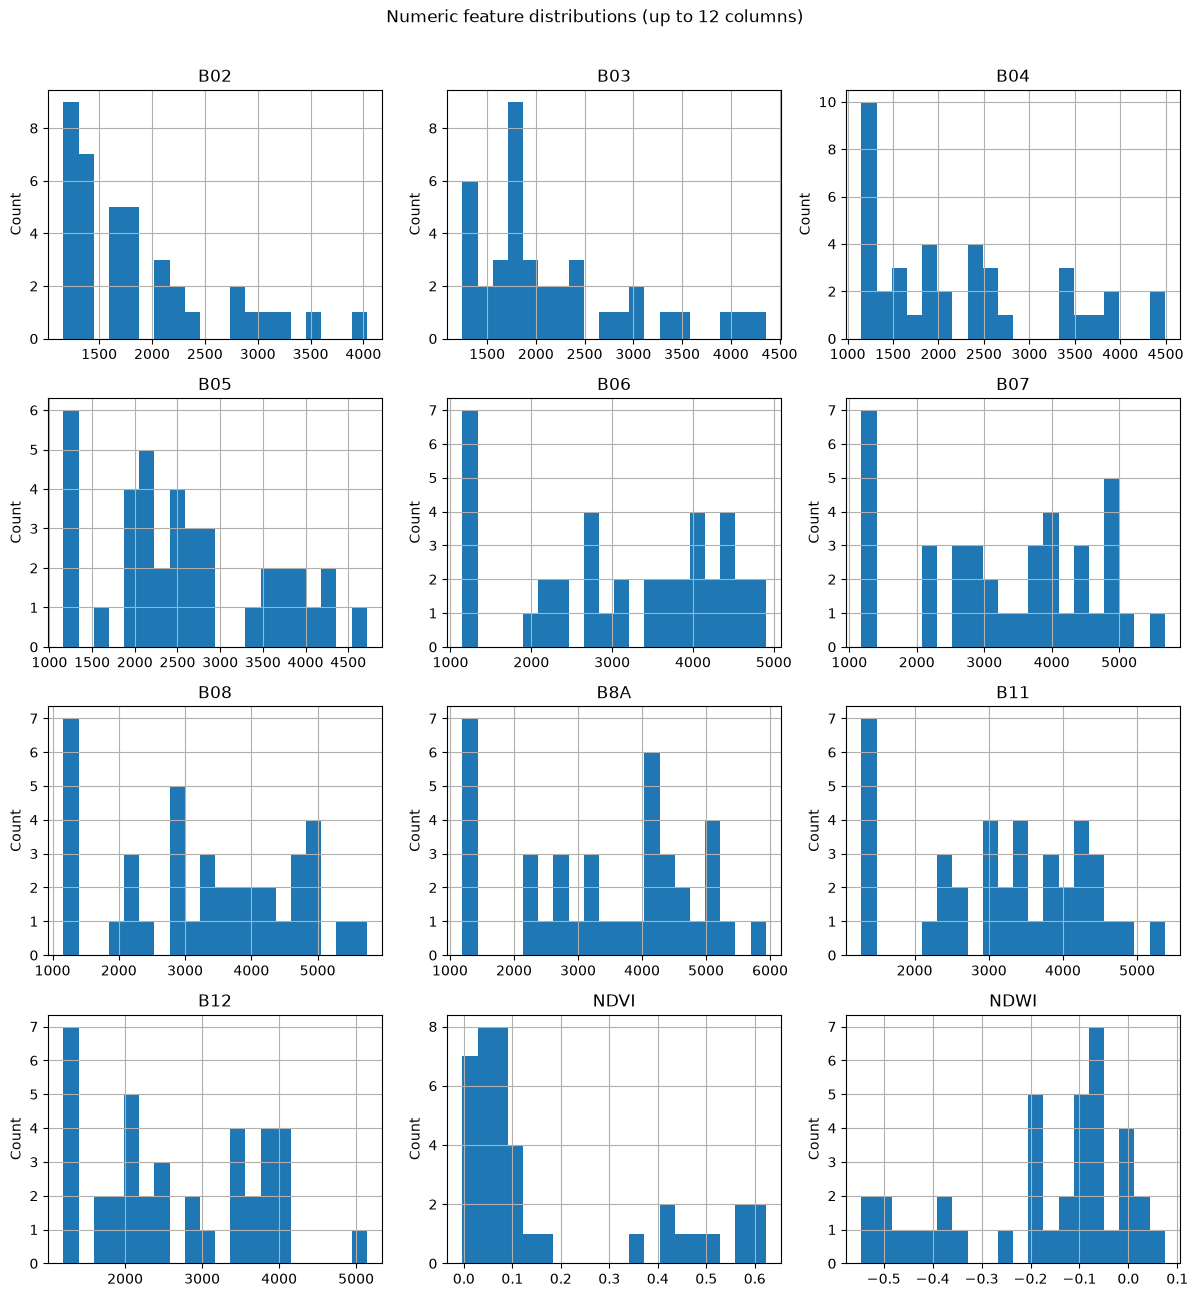

In [5]:
numeric_df = df.select_dtypes(include=[np.number])
print("Numeric feature columns:", len(numeric_df.columns))
if numeric_df.empty:
    print("No numeric columns available.")
else:
    display(numeric_df.describe().T)
    nunique = numeric_df.nunique(dropna=True)
    constant_cols = nunique[nunique <= 1].index.tolist()
    print("Numeric columns with at most one unique non-null value:", constant_cols or "None")

    feature_cols = [c for c in numeric_df.columns if c.lower() not in {"class_id", "sample_id", "point_id", "id"}]
    if feature_cols:
        cols = feature_cols[:12]
        ncols = 3
        nrows = int(np.ceil(len(cols) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.2 * nrows))
        axes = np.atleast_1d(axes).ravel()
        for ax, col in zip(axes, cols):
            numeric_df[col].dropna().hist(ax=ax, bins=20)
            ax.set_title(col)
            ax.set_ylabel("Count")
        for ax in axes[len(cols):]:
            ax.set_visible(False)
        fig.suptitle("Numeric feature distributions (up to 12 columns)", y=1.01)
        plt.tight_layout()
        plt.show()

## 5. Compare feature summaries by class

This is an exploratory comparison, not a statistical significance test. It can reveal overlap or possible outliers, but the small sample count means apparent separation may not generalize to unseen areas.

In [6]:
if label_col is None:
    print("Cannot group numeric features because no class label column exists.")
else:
    candidate_features = [
        c for c in numeric_df.columns
        if c.lower() not in {"class_id", "sample_id", "point_id", "id"}
    ]
    if not candidate_features:
        print("No numeric feature columns available for grouped summaries.")
    else:
        selected = candidate_features[:10]
        grouped = df.groupby(label_col, dropna=False)[selected].agg(["count", "median", "std"])
        display(grouped)

B02                       B03                       B04          \
           count  median         std count  median         std count  median   
class_name                                                                     
bare_soil      6  1755.5  256.955768     6  2102.0  404.345108     6  2458.5   
built_up       9  2907.0  639.431736     9  3296.0  723.517795     9  3532.0   
road           8  1792.0  216.757929     8  1878.0  275.091900     8  1990.0   
vegetation    10  1352.5   59.560986    10  1718.0  131.001442    10  1362.5   
water          6  1204.0   35.952283     6  1276.0   34.997143     6  1174.5   

                         B05  ...          B08   B8A                       \
                   std count  ...          std count  median          std   
class_name                    ...                                           
bare_soil   575.205963     6  ...   595.491730     6  3421.5   557.239147   
built_up    749.820645     9  ...   581.717715     9  4268.0   458.507028   
road        361.310882     8  ...   350.123958     8  2624.5   343.635163   
vegetation  143.660131    10  ...  1261.281623    10  5027.0  1270.563584   
water        24.451312     6  ...    52.748460     6  1246.5    58.984744   

             B11                       B12                      
           count  median         std count  median         std  
class_name                                                      
bare_soil      6  4115.5  608.816365     6  3805.5  623.801785  
built_up       9  4222.0  274.263154     9  3890.0  229.166485  
road           8  2543.5  421.133992     8  2212.0  437.668641  
vegetation    10  3190.0  673.840972    10  2017.0  389.402448  
water          6  1313.0   22.163032     6  1213.5   18.938497  

[5 rows x 30 columns]

## 6. Optional spatial coverage check

If a training-point GeoPackage exists, this section attempts to plot its geometries. It does not require GeoPandas for the rest of the notebook. The project has used files such as `data/aoi/training_samples.gpkg` and `data/aoi/training_samples_v2.gpkg`; the first available candidate is used for visualization only. Verify the file and layer correspond to the same labelled dataset before interpreting this plot.

Optional vector file: c:\Users\lenovo\Desktop\satellite-land-cover-classification\data\aoi\training_samples_v2.gpkg
Feature count: 39
CRS: EPSG:4326


,class_name,class_id
0,vegetation,1
1,built_up,2
2,bare_soil,3
3,water,4
4,road,5


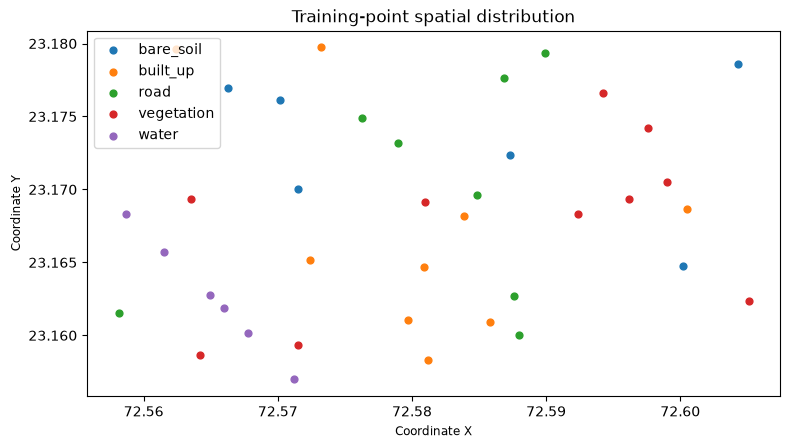

In [7]:
vector_candidates = [
    ROOT / "data" / "aoi" / "training_samples_v2.gpkg",
    ROOT / "data" / "aoi" / "training_samples.gpkg",
]
vector_path = next((p for p in vector_candidates if p.exists()), None)

if vector_path is None:
    print("No optional training-point GeoPackage found; skipping spatial plot.")
else:
    print("Optional vector file:", vector_path)
    try:
        import geopandas as gpd
        points = gpd.read_file(vector_path)
        print("Feature count:", len(points))
        print("CRS:", points.crs)
        display(points.drop(columns="geometry", errors="ignore").head())
        ax = points.plot(
            column=label_col if label_col and label_col in points.columns else None,
            categorical=True,
            legend=True if label_col and label_col in points.columns else False,
            figsize=(8, 6),
            markersize=24,
        )
        ax.set_title("Training-point spatial distribution")
        ax.set_xlabel("Coordinate X")
        ax.set_ylabel("Coordinate Y")
        plt.tight_layout()
        plt.show()
    except ImportError:
        print("GeoPandas is not installed; install it in the project environment to enable this optional plot.")
    except Exception as exc:
        print(f"Could not plot optional vector file: {type(exc).__name__}: {exc}")
        print("The tabular data checks above remain available.")

## 7. Interpretation and next steps

- Check whether each class has enough independent samples, not just a balanced row count.
- Investigate missing values, duplicate IDs, constant features, and unexpected feature ranges before modelling.
- Confirm that vector points and the CSV refer to the same cleaned training set.
- Keep validation points separate from training points. Random train/test splits can overestimate generalization when nearby points are spatially correlated.
- The project’s spatial cross-validation diagnostics have shown that some folds can be skipped when a training fold lacks a class (water was reported missing in one fold). Report evaluated folds and skipped folds transparently.
- Do not treat training-set metrics as independent map accuracy. With a small dataset, conclusions should remain cautious.

**No input data are modified by this notebook.**